## 1. Install Dependencies


Install the depencies needed to run this notebook and clone the github which contains helper scripts

In [ ]:
!apt-get update && apt-get install -y libsndfile1 ffmpeg
!pip install Cython packaging
!pip install nemo_toolkit['asr'] sentencepiece torchaudio scikit-learn

## 2. Imports and Utilities
Load all necessary modules and helper functions.

## 3. Configuration

In [ ]:
from datasets import load_dataset, load_from_disk

ds = load_dataset("RobotsMali/transcription-scorer")

/home/panga/rlnf/rlnf/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
train = ds["train"]
test = ds["test"]

In [32]:
test

Dataset({
    features: ['audio', 'duration', 'transcription', 'score', 'labeler'],
    num_rows: 216
})

In [5]:
train

Dataset({
    features: ['audio', 'duration', 'transcription', 'score', 'labeler'],
    num_rows: 1937
})

## CONFIGURATION

In [6]:
from config_rlnf import RLNFConfig
config = RLNFConfig() #DEFAULT CONFIG


config.save_pretrained("rlnf")

## FEATURE EXTRACTOR

In [8]:
from feature_extractor_rlnf import RLNFFeatureExtractor
feature_extractor = RLNFFeatureExtractor(config)

#feature_extractor.save_pretrained("rlnf")

[NeMo I 2025-07-26 22:56:07 features:305] PADDING: 16


## TOKENIZER

In [9]:
tokenizer_path = "./tokenizer.model"

In [10]:
from tokenizer_rlnf import RLNFSentencePieceTokenizer
tokenizer = RLNFSentencePieceTokenizer(tokenizer_path)

## PROCESSOR

In [11]:
from processor_rlnf import RLNFProcessor
processor = RLNFProcessor(feature_extractor=feature_extractor, tokenizer=tokenizer)

processor.save_pretrained("rlnf")

[]

## MAKE DATASET

In [12]:
import torch
from torch.utils.data import DataLoader
from dataset_rlnf import RLNFDataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def make_d(dataset) :

    return RLNFDataset(
        dataset,
        config="rlnf",
        tokenizer_model_path=tokenizer_path,
    )

def make_dl(dataset, device, shuffle = True) :

    return DataLoader(
        dataset,
        batch_size=8,
        shuffle=shuffle,
        collate_fn=RLNFDataset.collate,
        num_workers=0 if device.type == "cuda" else 8)


In [13]:
import os
from torch import optim
import torch
from torch import nn
import numpy as np

### Hyperparameters
epochs = 200  # Number of epochs to train
batch_size = 16     # Single Batch size for training and testting
lr = 1e-3   # Learning rate used by the optimizer
save_dir = './training'  # Directory to save checkpoints
checkpoint_dir = f'{save_dir}/checkpoints'

use_scheduler = True    # Whether to use a learning rate scheduler (if False, LR will be constant throughout training)
scheduler_step_size = 25  # Number of epochs before reducing LR (if use_scheduler)
scheduler_gamma = 0.8    # Factor by which to reduce LR (if use_scheduler)

seed = 42   # Random seed for reproducibility
plot = True     # Whether to plot the training and validation loss

# Reproducibility
torch.manual_seed(seed)
np.random.seed(seed)

# Create save directory
os.makedirs(save_dir, exist_ok=True)


## TRAINING AND EVAL

In [14]:
from reward_model_rlnf import RewardModelRLNF

print("Building model...")
model = RewardModelRLNF(config)

model.to(device)

optimizer = optim.Adam(model.parameters(), lr=lr)
criterion = nn.MSELoss()
scheduler = None
if use_scheduler:
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=scheduler_step_size, gamma=scheduler_gamma)
    print(f"Scheduler: StepLR(step_size={scheduler_step_size}, gamma={scheduler_gamma})")

Building model...
Scheduler: StepLR(step_size=25, gamma=0.8)


In [15]:
from train_utils import fit, evaluate

In [16]:
  
train_ds = make_d(train)
test_ds = make_d(test)


train_loader = make_dl(train_ds, device=device)
test_loader = make_dl(test_ds, device=device, shuffle=False)

[NeMo I 2025-07-26 22:56:46 features:305] PADDING: 16
[NeMo I 2025-07-26 22:56:46 features:305] PADDING: 16


In [17]:
train_ds[4]["input_ids"].numel()

4

In [19]:
next(iter(train_loader))

{'audio_feats': tensor([[[-0.4540, -0.2293,  0.4961,  ...,  0.0000,  0.0000,  0.0000],
          [-0.7099,  0.0149,  0.5387,  ...,  0.0000,  0.0000,  0.0000],
          [-0.5875,  0.3155,  0.8500,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [-1.3175, -1.3837, -1.4076,  ...,  0.0000,  0.0000,  0.0000],
          [-1.1768, -1.3145, -1.3072,  ...,  0.0000,  0.0000,  0.0000],
          [-1.2037, -1.2067, -1.2352,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[ 2.8665,  0.7460,  0.2056,  ...,  0.0000,  0.0000,  0.0000],
          [ 2.3761, -0.9564, -1.3435,  ...,  0.0000,  0.0000,  0.0000],
          [ 0.3683, -1.2038, -2.0073,  ...,  0.0000,  0.0000,  0.0000],
          ...,
          [ 2.3423, -0.2252, -0.8933,  ...,  0.0000,  0.0000,  0.0000],
          [-0.1558, -1.2187,  0.0283,  ...,  0.0000,  0.0000,  0.0000],
          [ 2.3297, -0.9580, -0.8011,  ...,  0.0000,  0.0000,  0.0000]],
 
         [[-1.9456, -2.2358, -2.2478,  ...,  0.0000,  0.0000,  0.0000],
          [-1

## 7. Training Loop

In [20]:
# Train the Reward model for {epochs} number of iterations over all training batches
history = fit(
    model=model,
    train_dataloader=train_loader,
    valid_dataloader=test_loader,
    epochs=epochs,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    checkpoint_dir="rlnf",
    scheduler=scheduler,
    
)

Début de l'entraînement…
Modèle sauvegardé : rlnf
Époch 1/200 — Train Loss: 0.0455 — Val Loss: 0.0161 — Val R2: 0.7041
Modèle sauvegardé : rlnf
Époch 2/200 — Train Loss: 0.0307 — Val Loss: 0.0124 — Val R2: 0.7732
Époch 3/200 — Train Loss: 0.0280 — Val Loss: 0.0307 — Val R2: 0.4381
Modèle sauvegardé : rlnf
Époch 4/200 — Train Loss: 0.0261 — Val Loss: 0.0118 — Val R2: 0.7836
Époch 5/200 — Train Loss: 0.0246 — Val Loss: 0.0141 — Val R2: 0.7421
Époch 6/200 — Train Loss: 0.0228 — Val Loss: 0.0141 — Val R2: 0.7408
Époch 7/200 — Train Loss: 0.0203 — Val Loss: 0.0166 — Val R2: 0.6954
Époch 8/200 — Train Loss: 0.0189 — Val Loss: 0.0160 — Val R2: 0.7068
Époch 9/200 — Train Loss: 0.0174 — Val Loss: 0.0179 — Val R2: 0.6717
Époch 10/200 — Train Loss: 0.0185 — Val Loss: 0.0162 — Val R2: 0.7028
Époch 11/200 — Train Loss: 0.0171 — Val Loss: 0.0180 — Val R2: 0.6696
Époch 12/200 — Train Loss: 0.0141 — Val Loss: 0.0215 — Val R2: 0.6067
Époch 13/200 — Train Loss: 0.0132 — Val Loss: 0.0229 — Val R2: 0.5801

## 8. Save Final Model & Logs

In [21]:
#final_path = os.path.join(save_dir, 'reward_model.ckpt')
#model.save(final_path)
import json

logs_path = os.path.join("rlnf/", 'training_logs.json')
with open(logs_path, 'w', encoding='utf-8') as f:
    json.dump(history, f, indent=2)
print(f"Saved training logs to {logs_path}")

Saved training logs to rlnf/training_logs.json


## 9. Evaluation & Plots

In [22]:
import matplotlib.pyplot as plt

In [23]:
import matplotlib.pyplot as plt

def plot_score_histogram(targets):
    plt.figure(figsize=(6, 4))
    plt.hist(targets, bins=30, color='skyblue', edgecolor='black')
    plt.title('Distribution des Scores cibles')
    plt.xlabel('Score')
    plt.ylabel('Nombre d\'exemples')
    plt.grid(True)
    plt.show()


Running final evaluation...


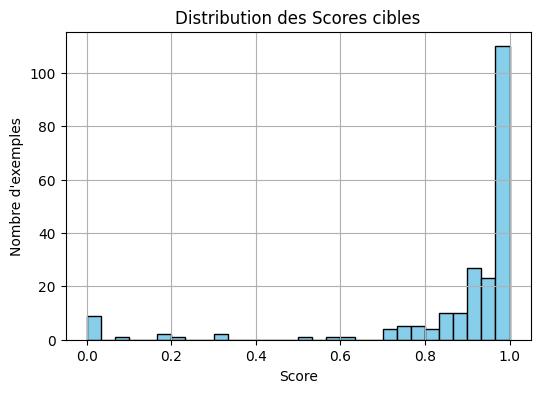

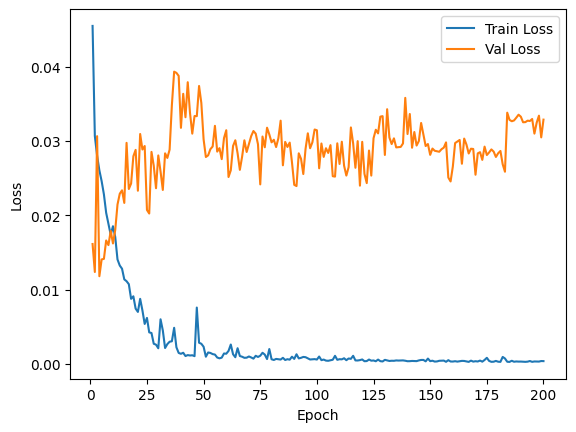

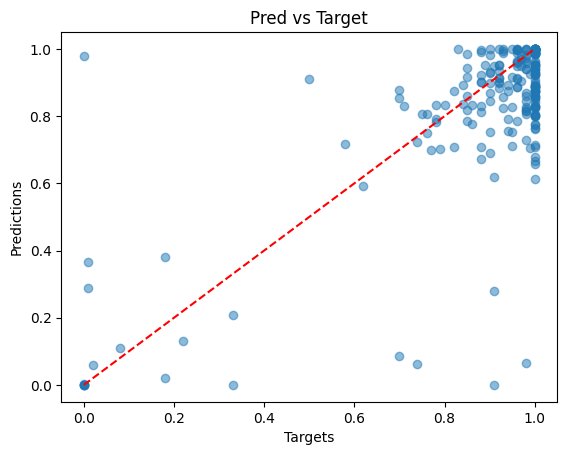

In [24]:
print("Running final evaluation...")
evaluate(model, test_loader, criterion, device)

if plot:
    preds, targets = [], []
    model.eval()
    with torch.no_grad():
        for batch in test_loader:
            audio       = batch['audio_feats'].to(device)
            audio_lens  = batch['audio_lengths'].to(device)
            text       = batch['input_ids'].long().to(device)
            text_lens  = batch['text_lengths'].long().to(device)
            labels      = batch['score'].to(device)

            out = model(audio, audio_lens, text, text_lens)
            preds.append(out.logits.cpu().numpy())
            targets.append(labels.cpu().numpy())
    preds = np.concatenate(preds)
    targets = np.concatenate(targets)
    
    plot_score_histogram(targets=targets)

    # Loss curves
    plt.figure()
    plt.plot(range(1, epochs+1), history['train_loss'], label='Train Loss')
    plt.plot(range(1, epochs+1), history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Predictions vs Targets  
    plt.figure()
    plt.scatter(targets, preds, alpha=0.5)
    plt.xlabel('Targets')
    plt.ylabel('Predictions')
    plt.title('Pred vs Target')
    plt.plot([0,1],[0,1], 'r--')
    plt.show()